# AAAIM Evaluation Test - UniProt

This notebook tests both single model evaluation and batch evaluation of multiple models.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import logging

# Add the project root to the Python path
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

# Import AAAIM functions
from core import annotate_model, curate_model
from utils.evaluation import (
    evaluate_single_model,
    evaluate_models_in_folder,
    print_evaluation_results,
    compare_results
)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# LLM configuration
# llm_model = "meta-llama/llama-3.3-70b-instruct:free"  # or "gpt-4o-mini"
llm_model = "Llama-3.3-70B-Instruct"

# Evaluation parameters
max_entities_per_model = 10  # Limit entities per model for testing
num_models_to_test = 5  # Number of models to test in batch evaluation

# Entity and database configuration
entity_type = "protein"
database = "uniprot"

output_dir = "./results/"  # Output directory for results

## Test 1: Single Model Evaluation

Evaluation of a single model with existing annotations.

In [2]:
test_model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/BIOMD0000000452.xml"
tax_id = 9606
# Check if test model exist

if os.path.exists(test_model_file):
    print(f"✓ Test model found: {test_model_file}")
else:
    print(f"✗ Test model not found: {test_model_file}")

✓ Test model found: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/BIOMD0000000452.xml


In [3]:
# Test with a single model
recommendations_df, metrics = annotate_model(
    model_file=test_model_file,
    llm_model=llm_model,
    max_entities=max_entities_per_model,
    entity_type=entity_type,
    database=database,
    tax_id=tax_id
)

2025-08-04 18:31:29,730 - INFO - Starting annotation for model: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/BIOMD0000000452.xml
2025-08-04 18:31:29,731 - INFO - Using LLM model: Llama-3.3-70B-Instruct
2025-08-04 18:31:29,731 - INFO - Using method: direct for database search
2025-08-04 18:31:29,731 - INFO - Entity type: protein, Database: uniprot
2025-08-04 18:31:29,732 - INFO - Using organism-specific search for tax_id: 9606
2025-08-04 18:31:29,732 - INFO - >>>Step 1: Getting species from model...<<<
2025-08-04 18:31:29,782 - INFO - Found 109 species in model
2025-08-04 18:31:29,830 - INFO - Found 106 entities with existing annotations
2025-08-04 18:31:29,830 - INFO - Selected 10 entities for annotation
2025-08-04 18:31:29,830 - INFO - >>>Step 2: Extracting model context...<<<
2025-08-04 18:31:30,060 - INFO - Extracted context for model: Bidkhori2012 - normal EGFR signalling
2025-08-04 18:31:30,061 - INFO - >>>Step 3: Querying LLM (Llama-3.3-70B-Instruct)...<<<
2025-08-04 18:31

In [4]:
recommendations_df

,file,type,id,display_name,annotation,annotation_label,match_score,existing,update_annotation
0,BIOMD0000000452.xml,protein,mwe2fff28d_182c_4a1c_9882_f17774c0958a,EGF,UNIPROT:P01133,EGF,0.333333,1,keep
1,BIOMD0000000452.xml,protein,mw93907b2d_53db_4080_9e3f_3eb304441ab9,EGFR,UNIPROT:P00533,EGFR,1.000000,1,keep
2,BIOMD0000000452.xml,protein,mw7eacabf9_d68c_491a_aba2_ec0809a8ecc8,EGF-EGFR,UNIPROT:P01133,EGF,0.333333,1,keep
3,BIOMD0000000452.xml,protein,mwa8f2e7b2_0927_4ab4_a817_dddc43bb4fa3,EGF-EGFR2,UNIPROT:P01133,EGF,0.333333,1,keep
4,BIOMD0000000452.xml,protein,mwbfcf6773_1915_432c_b1d2_1f246094cc74,pEGF-EGFR2,UNIPROT:P00533,EGFR,1.000000,1,keep
5,BIOMD0000000452.xml,protein,mw19122f7d_f92e_4dc0_922f_6b681db65b0b,cbl,UNIPROT:P22681,CBL,0.666667,1,keep
6,BIOMD0000000452.xml,protein,mw19122f7d_f92e_4dc0_922f_6b681db65b0b,cbl,UNIPROT:Q9Y4U1,MMACHC,0.333333,0,ignore
7,BIOMD0000000452.xml,protein,mw19122f7d_f92e_4dc0_922f_6b681db65b0b,cbl,UNIPROT:Q9ULV8,CBLC,0.333333,0,ignore
8,BIOMD0000000452.xml,protein,mw3c2e1b43_29ca_491a_93e9_c723a993d6fb,Shc,UNIPROT:P29353,SHC1,0.333333,0,ignore
9,BIOMD0000000452.xml,protein,mw3c2e1b43_29ca_491a_93e9_c723a993d6fb,Shc,UNIPROT:P98077,SHC2,0.333333,1,keep


In [5]:
metrics

{'total_entities_in_model': 109,
 'total_entities_annotated': 10,
 'entities_with_predictions': 10,
 'annotation_rate': 1.0,
 'total_predictions': 18,
 'matches': 8,
 'accuracy': 0.07547169811320754,
 'total_time': 7.848811149597168,
 'llm_time': 7.033133268356323,
 'search_time': 0.2500028610229492}

In [3]:
# Test using utils evaluation function
result_df = evaluate_single_model(
    model_file=test_model_file,
    tax_id=tax_id,
    llm_model=llm_model,
    max_entities=max_entities_per_model,
    entity_type=entity_type,
    database=database,
    save_llm_results=False,
    output_dir=output_dir
)

2025-08-04 18:38:36,113 - INFO - Evaluating model: BIOMD0000000452.xml
2025-08-04 18:38:36,113 - INFO - Using organism-specific search for tax_id: 9606
2025-08-04 18:38:36,175 - INFO - Evaluating 10 entities in BIOMD0000000452.xml
2025-08-04 18:38:46,252 - INFO - HTTP Request: POST https://api.llama.com/compat/v1/chat/completions "HTTP/1.1 200 OK"


In [4]:
result_df

,model,species_id,display_name,synonyms_LLM,reason,exist_annotation_id,exist_annotation_name,predictions,predictions_names,match_score,recall_formula,precision_formula,recall_exact,precision_exact,accuracy,total_time,llm_time,query_time,tax_id,tax_name
0,BIOMD0000000452.xml,mwe2fff28d_182c_4a1c_9882_f17774c0958a,EGF,"[EGF, EGF1, EGF2]","The model is an EGFR signaling pathway, and th...",[P01133],EGF,[P01133],EGF,[0.3333333333333333],0,0,1.000000,1.0,1,9.869732,9.617884,0.251848,9606,None
1,BIOMD0000000452.xml,mw93907b2d_53db_4080_9e3f_3eb304441ab9,EGFR,"[EGFR, ERBB1, HER1]","The model is an EGFR signaling pathway, and th...",[P00533],EGFR,[P00533],EGFR,[1.0],0,0,1.000000,1.0,1,9.869732,9.617884,0.251848,9606,None
2,BIOMD0000000452.xml,mw7eacabf9_d68c_491a_aba2_ec0809a8ecc8,EGF-EGFR,"[EGF, EGF1, EGF2]","The model is an EGFR signaling pathway, and th...","[P00533, P01133]","EGFR, EGF",[P01133],EGF,[0.3333333333333333],0,0,0.500000,1.0,1,9.869732,9.617884,0.251848,9606,None
3,BIOMD0000000452.xml,mwa8f2e7b2_0927_4ab4_a817_dddc43bb4fa3,EGF-EGFR2,"[EGFR, ERBB1, HER1]","The model is an EGFR signaling pathway, and th...","[P00533, P01133]","EGFR, EGF",[P00533],EGFR,[1.0],0,0,0.500000,1.0,1,9.869732,9.617884,0.251848,9606,None
4,BIOMD0000000452.xml,mwbfcf6773_1915_432c_b1d2_1f246094cc74,pEGF-EGFR2,"[EGFR, ERBB1, HER1]","The model is an EGFR signaling pathway, and th...","[P00533, P01133]","EGFR, EGF",[P00533],EGFR,[1.0],0,0,0.500000,1.0,1,9.869732,9.617884,0.251848,9606,None
5,BIOMD0000000452.xml,mw19122f7d_f92e_4dc0_922f_6b681db65b0b,cbl,"[CBL, CBL1, CBL2]","The model is an EGFR signaling pathway, and th...",[P22681],CBL,[P22681],CBL,[0.6666666666666666],0,0,1.000000,1.0,1,9.869732,9.617884,0.251848,9606,None
6,BIOMD0000000452.xml,mw3c2e1b43_29ca_491a_93e9_c723a993d6fb,Shc,"[SHC1, SHC, SHCA]","The model is an EGFR signaling pathway, and th...",[P98077],SHC2,[P29353],SHC1,[1.0],0,0,0.000000,0.0,0,9.869732,9.617884,0.251848,9606,None
7,BIOMD0000000452.xml,mw5198d3c2_879c_4f0d_b4f8_cd40efe0b1cf,pEGF-EGFR2-Shc,"[SHC1, SHC, SHCA]","The model is an EGFR signaling pathway, and th...","[P98077, P00533, P01133]","SHC2, EGFR, EGF",[P29353],SHC1,[1.0],0,0,0.000000,0.0,0,9.869732,9.617884,0.251848,9606,None
8,BIOMD0000000452.xml,mwe57c3282_5935_405c_8c0b_7fadb7a5de17,SHP,"[PTPN6, PTP1C, SHP1]","The model is an EGFR signaling pathway, and th...",[Q15466],NR0B2,[P29350],PTPN6,[0.6666666666666666],0,0,0.000000,0.0,0,9.869732,9.617884,0.251848,9606,None
9,BIOMD0000000452.xml,mw954e8fcb_ac0a_459d_8878_f19080208a17,pEGF-EGFR2-SHP2,"[EGFR, ERBB1, HER1]","The model is an EGFR signaling pathway, and th...","[Q15466, P00533, P01133]","NR0B2, EGFR, EGF",[P00533],EGFR,[1.0],0,0,0.333333,1.0,1,9.869732,9.617884,0.251848,9606,None


## Test 2: Batch Model Evaluation

Test the evaluation of multiple models in a directory.

In [5]:
model_dir = '/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/'

# Check if model directory exists
if os.path.exists(model_dir):
    model_files = [f for f in os.listdir(model_dir) if f.endswith('.xml')]
    print(f"✓ Model directory found: {model_dir}")
    print(f"  - Found {len(model_files)} SBML files")
    # print(f"  - Will test first {min(num_models_to_test, len(model_files))} models")

✓ Model directory found: /Users/luna/Desktop/CRBM/AMAS_proj/Models/BioModels/
  - Found 1063 SBML files


In [11]:
# Run batch evaluation 
batch_results_df = evaluate_models_in_folder(
    model_dir=model_dir,
    # num_models=20,
    llm_model=llm_model,
    entity_type=entity_type,
    database=database,
    save_llm_results=True,
    output_dir=output_dir,
    output_file="biomd_uniprot_direct_llama-3_top3_9606.csv",
    start_at=1,
    tax_id = 9606
)

2025-08-04 18:42:42,035 - WARNING - Skipping BIOMD0000000001.xml - no results generated
2025-08-04 18:42:42,044 - WARNING - Skipping BIOMD0000000002.xml - no results generated
2025-08-04 18:42:42,048 - WARNING - Skipping BIOMD0000000003.xml - no results generated
2025-08-04 18:42:42,053 - WARNING - Skipping BIOMD0000000004.xml - no results generated
2025-08-04 18:42:42,058 - WARNING - Skipping BIOMD0000000005.xml - no results generated
2025-08-04 18:42:42,062 - WARNING - Skipping BIOMD0000000006.xml - no results generated
2025-08-04 18:42:42,074 - WARNING - Skipping BIOMD0000000007.xml - no results generated
2025-08-04 18:42:42,080 - WARNING - Skipping BIOMD0000000008.xml - no results generated
2025-08-04 18:42:42,091 - WARNING - Skipping BIOMD0000000009.xml - no results generated
2025-08-04 18:42:42,097 - WARNING - Skipping BIOMD0000000010.xml - no results generated
2025-08-04 18:42:42,111 - WARNING - Skipping BIOMD0000000011.xml - no results generated
2025-08-04 18:42:42,119 - WARNIN

LLM results will be saved to: ./results/Llama-3.3-70B-instruct-Meta/protein/20250804_1842
Evaluating 1/1063: BIOMD0000000001.xml
Evaluating 2/1063: BIOMD0000000002.xml
Evaluating 3/1063: BIOMD0000000003.xml
Evaluating 4/1063: BIOMD0000000004.xml
Evaluating 5/1063: BIOMD0000000005.xml
Evaluating 6/1063: BIOMD0000000006.xml
Evaluating 7/1063: BIOMD0000000007.xml
Evaluating 8/1063: BIOMD0000000008.xml
Evaluating 9/1063: BIOMD0000000009.xml
Evaluating 10/1063: BIOMD0000000010.xml
Evaluating 11/1063: BIOMD0000000011.xml
Evaluating 12/1063: BIOMD0000000012.xml
Evaluating 13/1063: BIOMD0000000013.xml
Evaluating 14/1063: BIOMD0000000014.xml
Evaluating 15/1063: BIOMD0000000015.xml


2025-08-04 18:42:42,247 - WARNING - Skipping BIOMD0000000016.xml - no results generated
2025-08-04 18:42:42,258 - WARNING - Skipping BIOMD0000000017.xml - no results generated


Evaluating 16/1063: BIOMD0000000016.xml
Evaluating 17/1063: BIOMD0000000017.xml
Evaluating 18/1063: BIOMD0000000018.xml
LLM results saved to: results/Llama-3.3-70B-instruct-Meta/protein/20250804_1842/BIOMD0000000018.txt
Evaluating 19/1063: BIOMD0000000019.xml


2025-08-04 18:42:49,023 - WARNING - Skipping BIOMD0000000020.xml - no results generated
2025-08-04 18:42:49,031 - WARNING - Skipping BIOMD0000000021.xml - no results generated
2025-08-04 18:42:49,043 - WARNING - Skipping BIOMD0000000022.xml - no results generated
2025-08-04 18:42:49,052 - WARNING - Skipping BIOMD0000000023.xml - no results generated
2025-08-04 18:42:49,056 - WARNING - Skipping BIOMD0000000024.xml - no results generated
2025-08-04 18:42:49,060 - WARNING - Skipping BIOMD0000000025.xml - no results generated
2025-08-04 18:42:49,066 - WARNING - Skipping BIOMD0000000026.xml - no results generated
2025-08-04 18:42:49,070 - WARNING - Skipping BIOMD0000000027.xml - no results generated
2025-08-04 18:42:49,080 - WARNING - Skipping BIOMD0000000028.xml - no results generated
2025-08-04 18:42:49,086 - WARNING - Skipping BIOMD0000000029.xml - no results generated
2025-08-04 18:42:49,095 - WARNING - Skipping BIOMD0000000030.xml - no results generated
2025-08-04 18:42:49,099 - WARNIN

...

Evaluating 1055/1063: BIOMD0000001062.xml
Evaluating 1056/1063: BIOMD0000001063.xml


2025-08-04 19:24:20,404 - WARNING - Skipping BIOMD0000001063.xml - no results generated
2025-08-04 19:24:20,549 - WARNING - Skipping BIOMD0000001064.xml - no results generated
2025-08-04 19:24:20,634 - WARNING - Skipping BIOMD0000001065.xml - no results generated
2025-08-04 19:24:20,644 - WARNING - Skipping BIOMD0000001072.xml - no results generated


Evaluating 1057/1063: BIOMD0000001064.xml
Evaluating 1058/1063: BIOMD0000001065.xml
Evaluating 1059/1063: BIOMD0000001072.xml
Evaluating 1060/1063: BIOMD0000001077.xml


2025-08-04 19:24:37,159 - WARNING - Skipping BIOMD0000001078.xml - no results generated
2025-08-04 19:24:37,161 - WARNING - Skipping BIOMD0000001079.xml - no results generated


LLM results saved to: results/Llama-3.3-70B-instruct-Meta/protein/20250804_1842/BIOMD0000001077.txt
Evaluating 1061/1063: BIOMD0000001078.xml
Evaluating 1062/1063: BIOMD0000001079.xml
Evaluating 1063/1063: BIOMD0000001080.xml
LLM results saved to: results/Llama-3.3-70B-instruct-Meta/protein/20250804_1842/BIOMD0000001080.txt


In [12]:
print_evaluation_results(output_dir + "biomd_uniprot_direct_llama-3_top3_9606.csv", ref_results_csv = None)

Showing all results
Number of models assessed: 312
Number of models with predictions: 311
Number of annotations evaluated: 5322
Average accuracy (per model): 0.73
Ave. recall (formula): 0.00
Ave. precision (formula): 0.00
Ave. recall (exact): 0.68
Ave. precision (exact): 0.49
Average accuracy (per species): 0.68
Ave. recall (formula, per species): 0.00
Ave. precision (formula, per species): 0.00
Ave. recall (exact, per species): 0.59
Ave. precision (exact, per species): 0.47
Ave. total time (per model): 7.79
Ave. total time (per element, per model): 0.46
Ave. LLM time (per model): 7.62
Ave. LLM time (per element, per model): 0.45
Average number of predictions per species: 1.70


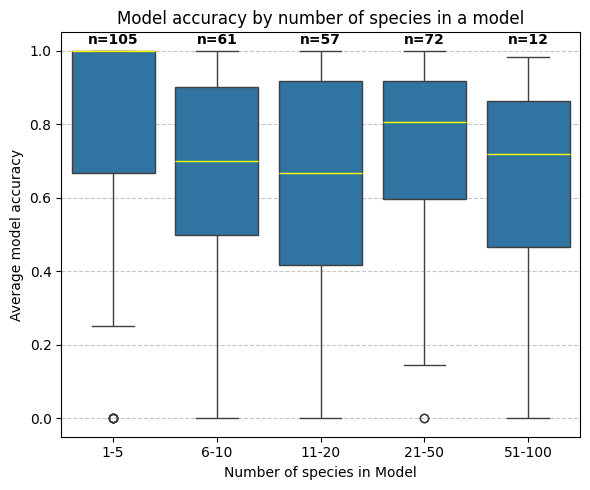

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
results_llama = pd.read_csv('results/biomd_uniprot_direct_llama-3_top3_9606.csv')
# Group models by number of species and calculate accuracy statistics
model_species_count = results_llama.groupby('model').size().reset_index(name='species_count')
model_accuracy = results_llama.groupby('model')['accuracy'].mean().reset_index()

# Merge the two dataframes
model_stats = pd.merge(model_species_count, model_accuracy, on='model')

# Create bins for species count to make the box plot more readable
bins = [0, 5, 10, 20, 50, 100]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100']
model_stats['species_count_bin'] = pd.cut(model_stats['species_count'], bins=bins, labels=labels)

# Count number of models in each bin
bin_counts = model_stats['species_count_bin'].value_counts().reindex(labels, fill_value=0)

# Create the box plot
plt.figure(figsize=(6, 5))
ax = sns.boxplot(x='species_count_bin', y='accuracy', data=model_stats, medianprops={"color": "yellow", "linewidth": 1})

# Add counts above each box
for i, label in enumerate(labels):
    count = bin_counts[label]
    ax.text(i, 1.01, f'n={count}', ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

plt.title('Model accuracy by number of species in a model')
plt.xlabel('Number of species in Model')
plt.ylabel('Average model accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'biomd_uniprot_direct_llama-3_top3_9606.png'), dpi=300, bbox_inches='tight')
plt.show()

## Functions test - qual model

In [1]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import logging
import libsbml

# Add the project root to the Python path
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

# Import AAAIM functions
from core import annotate_model, curate_model, model_info

In [2]:
model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/119_JNK-PATHWAY_source.sbml"
entity_type = "gene"
species_ids = model_info.get_all_species_ids(model_file, entity_type)
print(species_ids)
model_info.extract_model_info(model_file, species_ids, entity_type)

['csa1', 'csa2', 'csa4', 'csa5', 'csa3', 'csa12', 'sa4', 'sa5', 'sa12', 'sa16', 'sa17', 'sa18', 'sa33', 'sa34', 'sa36', 'sa75', 'sa76', 'sa77', 'sa78']


{'model_name': 'model_id',
 'model_type': <ModelType.SBML_QUAL: 'SBML-qual'>,
 'format_info': {'has_fbc': False,
  'has_qual': True,
  'num_species': 0,
  'num_reactions': 0,
  'num_qualitative_species': 19,
  'num_transitions': 13},
 'display_names': {'csa4': 'AP-1_complex',
  'sa36': 'TP53 signalling_phenotype',
  'csa2': 'MLK1/2/3_complex',
  'sa78': 'S',
  'csa3': 'MEKK1/4_complex',
  'sa17': 'Apoptosis_phenotype',
  'csa1': 'JNK_complex_cell',
  'sa75': '3b',
  'sa34': 'TP53_phosphorylated',
  'sa12': 'BCL2_phosphorylated',
  'sa16': 'Innate Immunity_phenotype',
  'sa33': 'ATF2_phosphorylated',
  'sa18': 'Autophagy_phenotype',
  'sa5': 'MAP2K7_phosphorylated',
  'sa4': 'MAP2K4_phosphorylated',
  'csa5': 'SARS-CoV-1 proteins_complex',
  'csa12': 'JNK_complex_cell',
  'sa76': '7a',
  'sa77': '3a'},
 'reactions': ['csa1 = ((sa4 | sa5 | sa76 | sa77) & csa12) | (csa12 & sa78)',
  'csa2 = csa5',
  'csa4 = csa1 | sa75',
  'csa3 = csa5',
  'sa4 = csa3 | csa5',
  'sa5 = csa2 | csa5',
  'sa

In [3]:
prompt = model_info.format_prompt(model_file, species_ids, entity_type)
print(prompt)

Now annotate these:
Gene to annotate: csa1, csa2, csa4, csa5, csa3, csa12, sa4, sa5, sa12, sa16, sa17, sa18, sa33, sa34, sa36, sa75, sa76, sa77, sa78
Model: "model_id" 
// Display Names:
{'csa4': 'AP-1_complex', 'sa36': 'TP53 signalling_phenotype', 'csa2': 'MLK1/2/3_complex', 'sa78': 'S', 'csa3': 'MEKK1/4_complex', 'sa17': 'Apoptosis_phenotype', 'csa1': 'JNK_complex_cell', 'sa75': '3b', 'sa34': 'TP53_phosphorylated', 'sa12': 'BCL2_phosphorylated', 'sa16': 'Innate Immunity_phenotype', 'sa33': 'ATF2_phosphorylated', 'sa18': 'Autophagy_phenotype', 'sa5': 'MAP2K7_phosphorylated', 'sa4': 'MAP2K4_phosphorylated', 'csa5': 'SARS-CoV-1 proteins_complex', 'csa12': 'JNK_complex_cell', 'sa76': '7a', 'sa77': '3a'}
// Boolean Transitions:
csa1 = ((sa4 | sa5 | sa76 | sa77) & csa12) | (csa12 & sa78)
csa2 = csa5
csa4 = csa1 | sa75
csa3 = csa5
sa4 = csa3 | csa5
sa5 = csa2 | csa5
sa12 = csa1
sa16 = csa4
sa17 = !sa12
sa18 = sa12
sa33 = csa1
sa34 = csa1
sa36 = sa34
// Notes:


Return up to 3 standardized n

In [4]:
model_file = "/Users/luna/Desktop/CRBM/AMAS_proj/Models/BioDivine/218_TCA-CYCLE_source.sbml"
reader = libsbml.SBMLReader()
document = reader.readSBML(model_file)
model = document.getModel().getPlugin("qual")
model.getPackageName()

'qual'

In [5]:
species_ids = model_info.get_all_species_ids(model_file, entity_type)
model_info.extract_model_info(model_file, species_ids, entity_type)

['csa1916', 'csa1897', 'csa1919', 'csa1898', 'csa1902', 'csa1899', 'csa1914', 'csa1949', 'csa1901', 'csa1921', 'csa1910', 'csa1895', 'csa1896', 'sa11864', 'sa12297', 'sa11889', 'sa11857', 'sa11975', 'sa11930', 'sa11896', 'sa11962', 'sa11966', 'sa11863', 'sa12216', 'sa11967', 'sa11923', 'sa11907', 'sa11979', 'sa11856', 'sa11976', 'sa11955', 'sa11883', 'sa11973', 'sa11932', 'sa11855', 'sa11946', 'sa11940', 'sa11935', 'sa11914', 'sa12001', 'sa11881', 'sa12294', 'sa11887', 'sa11945', 'sa11901', 'sa11950', 'sa11922', 'sa11980', 'sa11987', 'sa11852', 'sa11902', 'sa12024', 'sa11871', 'sa11944', 'sa11865', 'sa11867', 'sa12015', 'sa11908', 'sa11854', 'sa11964', 'sa11939', 'sa11938', 'sa12293', 'sa11929', 'sa12295', 'sa11972', 'sa11948', 'sa11927']


{'model_name': 'model_id',
 'model_type': <ModelType.SBML_QUAL: 'SBML-qual'>,
 'format_info': {'has_fbc': False,
  'has_qual': True,
  'num_species': 0,
  'num_reactions': 0,
  'num_qualitative_species': 68,
  'num_transitions': 34},
 'display_names': {'sa12024': 'pyruvate_simple_molecule_neuron',
  'csa1899': 'Succinyl-CoA_space_ligase_complex_mitochondrial_space_matrix',
  'csa1895': 'pyruvate_space_dehydrogenase_space_complex_complex_mitochondrial_space_matrix',
  'sa11939': 'oxaloacetate(2-)_simple_molecule',
  'csa1897': 'malate_space_dehydrogenase_space_2_complex',
  'sa11889': 'fumaric_space_acid_simple_molecule',
  'sa11962': 'GLUD1',
  'sa12294': 'GTP_simple_molecule',
  'sa11979': 'PC',
  'sa11901': 'ACSS1',
  'sa11987': 'ADHFE1',
  'csa1919': 'fumarate_space_hydratase_complex',
  'sa11927': 'Co2+_ion',
  'sa11863': 'GDP_simple_molecule',
  'sa11883': '(5-hydroxyindol-3-yl)acetaldehyde_simple_molecule',
  'sa11854': '(S)-malate(2-)_simple_molecule',
  'sa11935': 'succinyl-CoA

In [3]:
import os
from openai import OpenAI
client = OpenAI(api_key=os.getenv("LLAMA_API_KEY"),base_url="https://api.llama.com/compat/v1/")
response = client.chat.completions.create(
    model="Llama-3.3-70B-Instruct",
    messages=[
        {"role": "user", "content": "Which planet do humans live on?"}
    ],
    temperature=0.2,
    max_tokens=10000)
print(response.choices[0].message.content)

Humans live on the planet Earth.
